# Reproductions of Juno result

Step-by-step reproduction of Figures 2 and 4 (all physics, constants, and the needed covariance data are embedded). Only `numpy` and `matplotlib` are required dependencies.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogFormatterMathtext

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

# Set the values of constants
G_SI = 6.67430e-11
C_KM_S = 299_792.458
C_M_S = C_KM_S * 1.0e3
HBAR_EV_S = 6.582_119_569e-16

MU_KM = 1.266_865_341e8          # GM for Jupiter in units of km^3/s^2
MU_M = MU_KM * 1.0e9
M_JUP_KG = MU_M / G_SI
R_J_KM = 71_492.0
R_J_M = R_J_KM * 1.0e3

# Orbital parameters of Juno estimated from perijove 1 through perijove 17
T_ORBIT_S = 53.5 * 86_400.0
A_KM = (MU_KM * T_ORBIT_S**2 / (4.0 * np.pi**2)) ** (1.0 / 3.0)
A_M = A_KM * 1.0e3
ECC = 1.0 - 1.06 * R_J_KM / A_KM
INC, OMEGA = 1.57, 3.08
N_MAX = 10

print(f"a = {A_KM:.4e} km ({A_KM/R_J_KM:.1f} R_J), e = {ECC:.5f}, 1-e = {1-ECC:.5f}")

a = 4.0929e+06 km (57.3 R_J), e = 0.98148, 1-e = 0.01852


## Gravity precession derivatives (Appendix B + GR term)

`d<dw_g>/dJ_l` for `l=2..10` (linear-in-`J_l` coefficients of eqs. B.1-B.9) plus the GR `d/dmu` term.

In [ ]:
def _trig(inc, omega):
    return dict(
        cos_i=np.cos(inc), sin_i=np.sin(inc), csc_i=1.0/np.sin(inc),
        cos3i=np.cos(3*inc), cos5i=np.cos(5*inc),
        cos2i=np.cos(2*inc), cos4i=np.cos(4*inc), cos6i=np.cos(6*inc),
        cos8i=np.cos(8*inc), cos10i=np.cos(10*inc),
        sin2i=np.sin(2*inc), sin3i=np.sin(3*inc), sin4i=np.sin(4*inc), sin5i=np.sin(5*inc),
        sin_w=np.sin(omega), sin3w=np.sin(3*omega), sin5w=np.sin(5*omega), sin7w=np.sin(7*omega),
        cos2w=np.cos(2*omega), cos4w=np.cos(4*omega), cos6w=np.cos(6*omega), cos8w=np.cos(8*omega),
    )

def domega_dJl(l, a, e, inc, omega, RJ):
    """Coefficient of J_l in eqs. B.1-B.9 = d<dw_g>/dJ_l (unnormalised)."""
    e2, e4, e6, e8 = e**2, e**4, e**6, e**8
    em1 = e**2 - 1.0
    t = _trig(inc, omega); pi = np.pi
    cos_i, sin_i, csc_i = t["cos_i"], t["sin_i"], t["csc_i"]
    cos3i, cos5i = t["cos3i"], t["cos5i"]
    cos2i, cos4i, cos6i, cos8i, cos10i = t["cos2i"], t["cos4i"], t["cos6i"], t["cos8i"], t["cos10i"]
    sin2i, sin3i, sin4i, sin5i = t["sin2i"], t["sin3i"], t["sin4i"], t["sin5i"]
    sin_w, sin3w, sin5w, sin7w = t["sin_w"], t["sin3w"], t["sin5w"], t["sin7w"]
    cos2w, cos4w, cos6w, cos8w = t["cos2w"], t["cos4w"], t["cos6w"], t["cos8w"]

    if l == 2:
        return 3*pi*(3+5*cos2i)*RJ**2/(4*a**2*em1**2)
    if l == 3:
        return (3*pi*(-1-3*e2-4*cos2i+5*(1+7*e2)*cos4i)*csc_i*sin_w*RJ**3/(32*a**3*e*em1**3))
    if l == 4:
        return (1.0/(512*a**4*em1**4))*15*pi*(
            -27*(4+5*e2) + 2*(-6+5*e2)*cos2w
            + 4*cos2i*(-52-63*e2+2*(-2+7*e2)*cos2w)
            + 7*cos4i*(-28-27*e2+2*(2+9*e2)*cos2w))*RJ**4
    if l == 5:
        return (1.0/(1024*a**5*e*em1**5))*15*pi*(
            (4+41*e2+18*e4)*(2*sin_i+7*(sin3i+3*sin5i))*sin_w
            + 28*e2*(1+2*e2)*(7+9*cos2i)*sin_i**3*sin3w
            - e2*cos_i*((4+3*e2)*(2*cos_i+21*(cos3i+5*cos5i))*csc_i*sin_w
                        + 7*e2*(2*sin2i+15*sin4i)*sin3w))*RJ**5
    if l == 6:
        return (1.0/(32768*a**6*em1**6))*105*pi*(
            2256*cos4i + 2376*cos6i
            + 5*((472+1940*e2+675*e4)*cos2i + 3*e2*(2*(292+99*e2)*cos4i+11*(44+13*e2)*cos6i))
            - 5*(10*e2*(6+7*e2)+(-68+254*e2+195*e4)*cos2i+6*(-4+102*e2+55*e4)*cos4i
                 +33*(4+34*e2+13*e4)*cos6i)*cos2w
            + 50*(24+100*e2+35*e4+4*cos2w)
            - 6*e2*(-28+45*e2+4*(-4+33*e2)*cos2i+11*(4+13*e2)*cos4i)*cos4w*sin_i**2)*RJ**6
    if l == 7:
        return (1.0/(524288*a**7*e*em1**7))*21*pi*sin_i**3*(
            -5*(25*(8+148*e2+205*e4+35*e6)+(448+6592*e2+7240*e4+900*e6)*cos2i
                +12*(56-5*e2*(-76+41*e2+33*e4))*cos4i-132*(-16-80*e2+65*e4*(2+e2))*cos6i
                -429*(8+212*e2+365*e4+75*e6)*cos8i)*csc_i**4*sin_w
            + 30*e2*(14*(15+7*e2)*(-8+27*e2)+(-2280+13687*e2+6237*e4)*cos2i
                     +22*(24+967*e2+351*e4)*cos4i+143*(24+151*e2+45*e4)*cos6i)*csc_i**2*sin3w
            + 264*e4*(-45+77*e2+4*(-5+52*e2)*cos2i+65*(1+3*e2)*cos4i)*sin5w)*RJ**7
    if l == 8:
        return (1.0/(16777216*a**8*em1**8))*63*pi*(
            5*(-1225*(192+35*e2*(48+56*e2+9*e4))
               -280*(1664+7*e2*(2064+2400*e2+385*e4))*cos2i
               -308*(1472+7*e2*(1776+2040*e2+325*e4))*cos4i
               -3432*(128+7*e2*(144+160*e2+25*e4))*cos6i
               -715*(704+7*e2*(624+600*e2+85*e4))*cos8i)
            + 70*(35*(-96+208*e2+950*e4+225*e6)+16*(-384+1648*e2+5160*e4+1155*e6)*cos2i
                  +44*(-96+1360*e2+2870*e4+585*e6)*cos4i+2288*e2*(48+80*e2+15*e4)*cos6i
                  +143*(96+1328*e2+1610*e4+255*e6)*cos8i)*cos2w
            + 616*e2*(6*(-280+944*e2+363*e4)+(-1960+14128*e2+4797*e4)*cos2i
                      +26*(40+688*e2+195*e4)*cos4i+65*(40+208*e2+51*e4)*cos6i)*cos4w*sin_i**2
            + 4576*e4*(-22+39*e2+4*(-2+25*e2)*cos2i+5*(6+17*e2)*cos4i)*cos6w*sin_i**4)*RJ**8
    if l == 9:
        return (1.0/(67108864*a**9*e*em1**9))*45*pi*sin_i**5*(
            7*(98*(64+1968*e2+5768*e4+3325*e6+315*e8)
               +14*(960+25808*e2+67032*e4+33635*e6+2695*e8)*cos2i
               -88*(-192-3344*e2-3864*e4+1225*e6+455*e8)*cos4i
               -429*(-64+7*e2*(-80+232*e2+405*e4+65*e6))*cos6i
               -286*(-320+7*e2*(-528+488*e2+1465*e4+255*e6))*cos8i
               -2431*(64+2608*e2+9128*e4+6125*e6+665*e8)*cos10i)*csc_i**6*sin_w
            - 4312*e2*(21*(-80+372*e2+705*e4+121*e6)+28*(-96+712*e2+1178*e4+195*e6)*cos2i
                       +52*(-16+580*e2+773*e4+119*e6)*cos4i+52*(32+744*e2+834*e4+119*e6)*cos6i
                       +221*(16+156*e2+147*e4+19*e6)*cos8i)*csc_i**4*sin3w
            - 32032*e4*(22*(-12+43*e2+13*e4)+(-276+2213*e2+605*e4)*cos2i
                        +(200+2462*e2+578*e4)*cos4i+17*(20+91*e2+19*e4)*cos6i)*csc_i**2*sin5w
            - 4576*e6*(-91+165*e2+4*(-7+102*e2)*cos2i+17*(7+19*e2)*cos4i)*sin7w)*RJ**9
    if l == 10:
        return (1.0/(2147483648*a**10*em1**10))*495*pi*(
            7*(23814*(128+3*e2*(640+1568*e2+840*e4+77*e6))
               +294*(20608+307584*e2+751968*e4+402360*e6+36855*e8)*cos2i
               +312*(19072+279936*e2+679392*e4+362040*e6+33075*e8)*cos4i
               +1053*(5504+21*e2*(3712+8864*e2+4680*e4+425*e6))*cos6i
               +442*(12928+21*e2*(8064+18528*e2+9560*e4+855*e6))*cos8i
               +4199*(1664+3*e2*(5760+7*e2*(1632+760*e2+63*e4)))*cos10i)
            - 84*(294*(-192+544*e2+6020*e4+4802*e6+539*e8)
                  +98*(-1088+5344*e2+42028*e4+32158*e6+3549*e8)*cos2i
                  +104*(-832+10720*e2+55356*e4+39102*e6+4165*e8)*cos4i
                  +13*(-3648+156640*e2+626444*e4+411278*e6+42245*e8)*cos6i
                  +442*(64+7328*e2+24276*e4+14826*e6+1463*e8)*cos8i
                  +4199*(64+1312*e2+3220*e4+1666*e6+147*e8)*cos10i)*cos2w
            - 8736*e2*(33*(-224+1208*e2+1600*e4+221*e6)+24*(-448+3896*e2+4680*e4+627*e6)*cos2i
                       +4*(-224+30040*e2+30432*e4+3825*e6)*cos4i+136*(64+920*e2+808*e4+95*e6)*cos6i
                       +323*(32+248*e2+192*e4+21*e6)*cos8i)*cos4w*sin_i**2
            - 1248*e4*(26*(-924+3418*e2+855*e4)+(-23100+199186*e2+45747*e4)*cos2i
                       +238*(84+850*e2+171*e4)*cos4i+323*(84+346*e2+63*e4)*cos6i)*cos6w*sin_i**4
            - 7072*e6*(-120+221*e2+4*(-8+133*e2)*cos2i+19*(8+21*e2)*cos4i)*cos8w*sin_i**6)*RJ**10
    raise ValueError(l)

def domega_dmu(a, e):
    return 6.0*np.pi/(a*(1.0-e**2)*C_KM_S**2)

def gradient_vector(a, e, inc, omega, RJ, n_max=10, apply_normalization=False):
    """[d/dmu, d/dJ2, ..., d/dJ_nmax]. apply_normalization=False reproduces the paper."""
    grad = [domega_dmu(a, e)]
    for l in range(2, n_max + 1):
        d = domega_dJl(l, a, e, inc, omega, RJ)
        if apply_normalization:
            d *= np.sqrt(2*l + 1)
        grad.append(d)
    return np.array(grad)

## Covariance matrix and sigma_omega (eq. 3.5)

The `[GM, J2..J10]` block of the Durante covariance is embedded below, then contracted with the gradient. Those coefficients are fully-normalised; the paper's value is reproduced by contracting them directly with the unnormalised-form derivatives (`apply_normalization=False`).

In [ ]:
# [GM, J2, ..., J10] covariance matrix extracted from the supporting data file
# included in the link to the Durante paper, with only the relevant 10 by 10 included.
COV_GM_J = np.array([
    [70.46, 2.318e-09, -4.629e-11, -1.584e-10, -2.058e-11, 2.678e-11, -4.552e-11, 7.314e-11, -1.096e-10, 2.1e-10],
    [2.318e-09, 5.703e-19, -4.222e-19, 2.918e-19, -3.743e-19, 4.109e-19, -5.579e-19, 6.234e-19, -8.617e-19, 9.329e-19],
    [-4.629e-11, -4.222e-19, 1.541e-18, -5.734e-19, 1.156e-18, -1.152e-18, 1.814e-18, -2.355e-18, 3.183e-18, -4.705e-18],
    [-1.584e-10, 2.918e-19, -5.734e-19, 6.411e-19, -7.783e-19, 1.182e-18, -1.416e-18, 2.131e-18, -2.469e-18, 3.625e-18],
    [-2.058e-11, -3.743e-19, 1.156e-18, -7.783e-19, 1.614e-18, -1.956e-18, 3.27e-18, -4.267e-18, 6.421e-18, -8.559e-18],
    [2.678e-11, 4.109e-19, -1.152e-18, 1.182e-18, -1.956e-18, 3.418e-18, -4.95e-18, 8.233e-18, -1.134e-17, 1.798e-17],
    [-4.552e-11, -5.579e-19, 1.814e-18, -1.416e-18, 3.27e-18, -4.95e-18, 9.162e-18, -1.392e-17, 2.286e-17, -3.384e-17],
    [7.314e-11, 6.234e-19, -2.355e-18, 2.131e-18, -4.267e-18, 8.233e-18, -1.392e-17, 2.529e-17, -3.929e-17, 6.622e-17],
    [-1.096e-10, -8.617e-19, 3.183e-18, -2.469e-18, 6.421e-18, -1.134e-17, 2.286e-17, -3.929e-17, 6.932e-17, -1.124e-16],
    [2.1e-10, 9.329e-19, -4.705e-18, 3.625e-18, -8.559e-18, 1.798e-17, -3.384e-17, 6.622e-17, -1.124e-16, 2.001e-16],
])

def covariance_slice(n_max=10):
    return COV_GM_J[:n_max, :n_max]

def sigma_omega(a=A_KM, e=ECC, inc=INC, omega=OMEGA, RJ=R_J_KM, n_max=N_MAX,
                apply_normalization=False):
    g = gradient_vector(a, e, inc, omega, RJ, n_max, apply_normalization)
    return np.sqrt(g @ covariance_slice(n_max) @ g)

SIGMA_OMEGA = sigma_omega()
print(f"sigma_omega (N=10) = {SIGMA_OMEGA:.3e}   [paper ~9.0e-10]")
print("sigma_omega vs N:", {n: round(float(sigma_omega(n_max=n)), 12) for n in (2, 4, 6, 8, 10)})

sigma_omega (N=10) = 9.332e-10   [paper ~9.0e-10]
sigma_omega vs N: {2: 8.07e-10, 4: 8.84e-10, 6: 9.16e-10, 8: 9.29e-10, 10: 9.33e-10}


## Density profile and fifth-force precession (eqs. 2.3-2.5)

Calculate the volume integral numerically from the above equation

In [ ]:
def polytrope_n1(n_points=1500, R=R_J_M, total_mass=M_JUP_KG):
    r = np.linspace(0.0, R, n_points)
    x = np.pi * r / R
    shape = np.ones_like(x)
    shape[x > 0] = np.sin(x[x > 0]) / x[x > 0]
    shape = np.clip(shape, 0.0, None)
    m = np.trapezoid(4.0 * np.pi * r**2 * shape, r)
    return r, shape * (total_mass / m)

def g_finite_size(lam_m, a_m=A_M, e=ECC, n_f=1440):
    """Per-orbit g(lambda) = <Delta omega>/alpha including Jupiter's finite size."""
    lam = np.atleast_1d(np.asarray(lam_m, dtype=float))
    rp, rho = polytrope_n1()
    M = np.trapezoid(4.0 * np.pi * rp**2 * rho, rp)
    f = np.linspace(0.0, 2.0 * np.pi, n_f)
    r = a_m * (1.0 - e**2) / (1.0 + e * np.cos(f))
    cosf = np.cos(f); rho_rp = rho * rp
    out = np.empty_like(lam)
    for k, L in enumerate(lam):
        kernel = 0.5 * (np.exp((rp[None, :] - r[:, None]) / L)
                        - np.exp(-(rp[None, :] + r[:, None]) / L))
        inner = np.trapezoid(rho_rp[None, :] * kernel, rp, axis=1)
        out[k] = -(4.0 * np.pi * L / (e * M)) * np.trapezoid(cosf * (1.0 + r / L) * inner, f)
    return out if out.size > 1 else out[0]

print(f"g(1e8 m) = {g_finite_size(1e8):.4f}  ->  <Delta omega>(alpha=1e-9) = {1e-9*g_finite_size(1e8):.3e}")

g(1e8 m) = -1.5163  ->  <Delta omega>(alpha=1e-9) = -1.516e-09


## Plot helpers

Small helpers so the figure plotting stays short (ie encode the common log scale in each figure)

In [ ]:
decades = lambda lo, hi, step=1: [10.0**k for k in range(lo, hi + 1, step)]

def style_log(ax, xlim, ylim, xlabel, ylabel, xticks, yticks):
    ax.set(xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticks(xticks); ax.set_yticks(yticks)
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.grid(True, which="both", ls=":", alpha=0.4)

def add_mass_axis(ax, exps):
    conv = lambda l: np.divide(HBAR_EV_S * C_M_S, np.asarray(l, float),
                               out=np.full_like(np.asarray(l, float), np.inf),
                               where=np.asarray(l, float) != 0)
    sec = ax.secondary_xaxis("top", functions=(conv, conv))
    sec.set_xlabel(r"$m_*$ [eV]")
    sec.xaxis.set_major_locator(FixedLocator([10.0**k for k in exps]))
    sec.xaxis.set_major_formatter(LogFormatterMathtext())

## Figure 2 - fifth-force precession drift

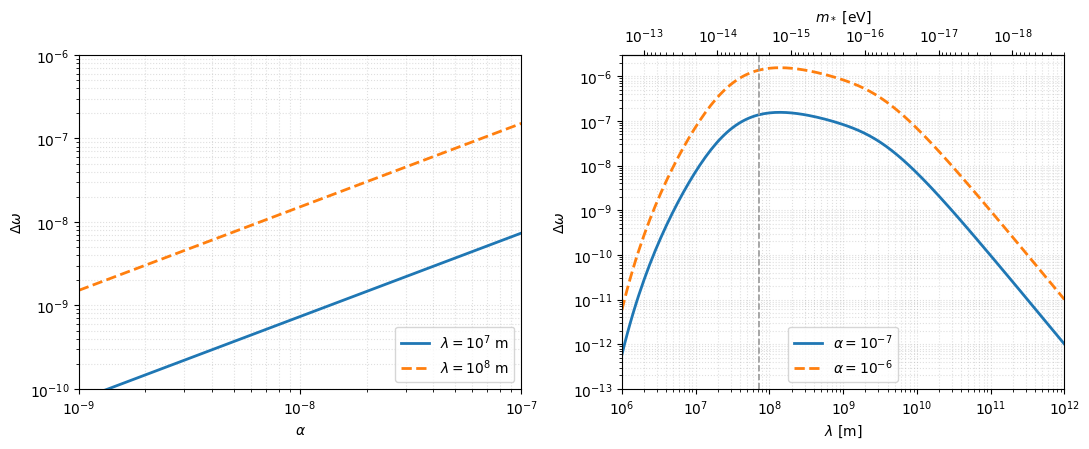

In [ ]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 4.6))

# left: drift vs coupling alpha, at fixed range lambda
alpha = np.logspace(-9, -7, 50)
for lam0, ls in [(1e7, "C0-"), (1e8, "C1--")]:
    axL.loglog(alpha, alpha * abs(g_finite_size(lam0)), ls, lw=2.0,
               label=rf"$\lambda = 10^{{{int(np.log10(lam0))}}}$ m")
style_log(axL, (1e-9, 1e-7), (1e-10, 1e-6), r"$\alpha$", r"$\Delta\omega$",
          decades(-9, -7), decades(-10, -6))
axL.legend(loc="lower right")

# right: drift vs range lambda, at fixed coupling alpha
lam = np.logspace(6, 12, 160)
g = np.abs(g_finite_size(lam))
for a0, ls in [(1e-7, "C0-"), (1e-6, "C1--")]:
    axR.loglog(lam, a0 * g, ls, lw=2.0, label=rf"$\alpha = 10^{{{int(np.log10(a0))}}}$")
axR.axvline(R_J_M, ls="--", color="0.6", lw=1.2)
style_log(axR, (1e6, 1e12), (1e-13, 3e-6), r"$\lambda$ [m]", r"$\Delta\omega$",
          decades(6, 12), decades(-13, -6))
axR.legend(loc="lower center")
add_mass_axis(axR, range(-13, -19, -1))

fig.tight_layout(); plt.show()

## Figure 4 - Juno fifth-force bound

`alpha_limit(lambda) = sigma_omega / |g(lambda)|`: the smallest detectable coupling at each range.

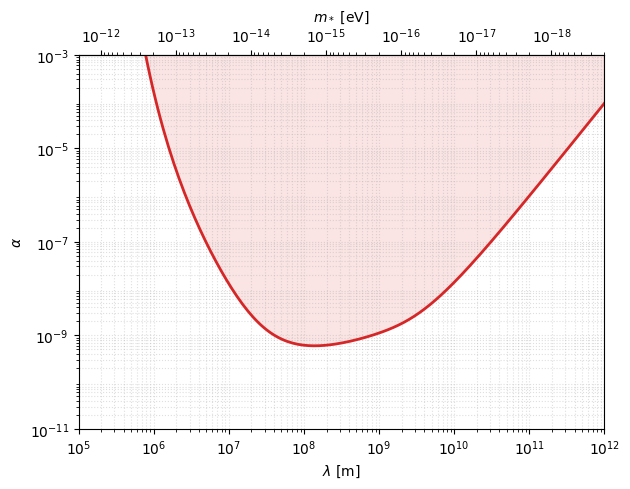

best bound: alpha >~ 5.98e-10 at lambda = 1.35e+08 m


In [ ]:
lam = np.logspace(5, 12, 200)
alpha_limit = SIGMA_OMEGA / np.abs(g_finite_size(lam))

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_limit, "C3-", lw=2.0)
ax.fill_between(lam, alpha_limit, 1e-3, color="C3", alpha=0.12)  # excluded region
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
fig.tight_layout(); plt.show()

i = int(np.argmin(alpha_limit))
print(f"best bound: alpha >~ {alpha_limit[i]:.2e} at lambda = {lam[i]:.2e} m")